# RAG Project — Medical Transcriptions Q&A

**Dataset:** [Medical Transcriptions Dataset (Kaggle)](https://www.kaggle.com/datasets/tboyle10/medicaltranscriptions) — file `mtsamples.csv`

This notebook builds a **simple Retrieval-Augmented Generation (RAG) system** on top of real medical
transcription reports, using the same style and tools as Lab5 → Lab8:

- `pandas` / `numpy` for data handling
- `nltk` for text preprocessing (Lab5)
- `scikit-learn` TF-IDF for classic retrieval (Lab6)
- `sentence-transformers` for semantic embeddings (Lab7)
- `faiss` for fast similarity search + a small `transformers` model for answer generation (Lab8)

No LangChain / LlamaIndex / Haystack / Docker / FastAPI — everything is built **from scratch, step by
step**, so every line can be understood.

## Implementation Plan

1. **Load & explore** the raw CSV — check shape, columns, dtypes, missing values, duplicates.
2. **Pick the right columns.** We do not assume names in advance — we search the columns for the ones
   that actually hold the transcription text, the specialty, and the short description.
3. **Clean** the text: drop duplicates/empty rows, normalize whitespace, remove only truly unsafe
   characters — **never** touch numbers, units, or medical terms.
4. **Preprocess a *copy* of the text for TF-IDF** (lowercase, tokenize, remove stopwords, lemmatize) —
   this copy is only used for the classic TF-IDF demo. The text used for embeddings/RAG stays close to
   the original, because transformer models understand raw language better than "cleaned" tokens.
5. **TF-IDF retrieval** — quick demo of Lab6-style keyword search, so we can compare it later.
6. **Embeddings** with `all-MiniLM-L6-v2` — turn every document (or chunk) into a 384-dim vector.
7. **Check document length** — medical reports are long, so we will likely need to **chunk** them
   (300–500 words, ~50 words overlap) instead of embedding a whole report as one vector.
8. **Build a FAISS index** over the chunk embeddings, storing the chunk text + specialty + description
   as metadata next to each vector.
9. **Retrieval function** — given a question, embed it and pull the Top-3 most similar chunks with
   their similarity scores.
10. **RAG pipeline** — Question → Embedding → FAISS → Top-3 chunks → build a context string → feed a
    small Hugging Face text2text model (`flan-t5-small`) → final answer.
11. **Test** with 10+ real medical questions and eyeball the retrieval quality.
12. **Compare** TF-IDF vs semantic retrieval on the same queries.

We always choose the **simplest correct option** at every step (e.g. `IndexFlatIP` in FAISS instead of
an approximate index, since our dataset is small).


## 1. Install Libraries

Run this once. If you already have these packages installed, this cell is safe to re-run (it will just confirm they're satisfied).

In [6]:
# Only the libraries allowed by the project spec.
# -q keeps the install output short (quiet mode).
!pip install -q pandas numpy nltk scikit-learn sentence-transformers faiss-cpu transformers matplotlib


## 2. Imports

In [7]:
import os
import re
import json
import numpy as np
import pandas as pd

# NLTK: classic text preprocessing (same tools as Lab5)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# scikit-learn: TF-IDF + cosine similarity (Lab6)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# sentence-transformers: semantic embeddings (Lab7)
from sentence_transformers import SentenceTransformer

# faiss: fast vector search (Lab8)
import faiss

# transformers: small generation model for the RAG "answer" step (Lab8)
from transformers import pipeline

# matplotlib: optional, only for the document-length histogram
import matplotlib.pyplot as plt

# Download the small NLTK data files we need (only downloads if missing)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

pd.set_option("display.max_colwidth", 120)
print("All libraries imported successfully.")


All libraries imported successfully.


## 3. Load Dataset

Download `mtsamples.csv` from the
[Kaggle dataset page](https://www.kaggle.com/datasets/tboyle10/medicaltranscriptions) and place it in a
`data/` folder next to this notebook (i.e. `data/mtsamples.csv`).

The cell below:
1. Looks for the file in a few likely locations.
2. Optionally tries the Kaggle API if you have it configured (`kaggle.json` set up) — this is skipped
   automatically if Kaggle isn't configured, no error is raised.


In [8]:
DATA_CANDIDATES = [
    "data/mtsamples.csv",
    "mtsamples.csv",
    "/mnt/user-data/uploads/mtsamples.csv",
]

csv_path = next((p for p in DATA_CANDIDATES if os.path.exists(p)), None)

# Optional: try downloading via the Kaggle API if the file wasn't found locally
# and the Kaggle CLI + credentials are available. This block never crashes the
# notebook if Kaggle isn't set up -- it just silently moves on.
if csv_path is None:
    try:
        os.makedirs("data", exist_ok=True)
        exit_code = os.system(
            "kaggle datasets download -d tboyle10/medicaltranscriptions -p data --unzip"
        )
        if exit_code == 0 and os.path.exists("data/mtsamples.csv"):
            csv_path = "data/mtsamples.csv"
    except Exception as e:
        print("Kaggle API not available, skipping automatic download:", e)

if csv_path is None:
    raise FileNotFoundError(
        "Could not find mtsamples.csv. Please download it from "
        "https://www.kaggle.com/datasets/tboyle10/medicaltranscriptions "
        "and place it at data/mtsamples.csv"
    )

df_raw = pd.read_csv(csv_path)
print(f"Loaded '{csv_path}' -> shape {df_raw.shape}")
df_raw.head()


Loaded 'data/mtsamples.csv' -> shape (4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with complaint of allergies.,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female presents with complaint of allergies. She used to have allergies when s...","allergy / immunology, allergic rhinitis, allergies, asthma, nasal sprays, rhinitis, nasal, erythematous, allegra, sp..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climbing stairs, difficulty with airline seats, tying shoes, used to public...","bariatrics, laparoscopic gastric bypass, weight loss programs, gastric bypass, atkin's diet, weight watcher's, body ..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC today. He is a very pleasant gentleman who is 42 years old, 344 pound...","bariatrics, laparoscopic gastric bypass, heart attacks, body weight, pulmonary embolism, potential complications, sl..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement with left atrial diameter of 4.7 cm.,2. Normal size right and left ventr...","cardiovascular / pulmonary, 2-d m-mode, doppler, aortic valve, atrial enlargement, diastolic function, ejection frac..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall thickness appear normal. The wall motion and left ventricular systoli...,"cardiovascular / pulmonary, 2-d, doppler, echocardiogram, annular, aortic root, aortic valve, atrial, atrium, calcif..."


## 4. Exploratory Data Analysis (EDA)

We inspect the raw data *before* touching anything, exactly like Lab5.

In [9]:
print("Shape (rows, columns):", df_raw.shape)
print("\nColumn names:", list(df_raw.columns))


Shape (rows, columns): (4999, 6)

Column names: ['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


In [10]:
df_raw.dtypes


Unnamed: 0           int64
description            str
medical_specialty      str
sample_name            str
transcription          str
keywords               str
dtype: object

In [11]:
df_raw.head()


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with complaint of allergies.,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female presents with complaint of allergies. She used to have allergies when s...","allergy / immunology, allergic rhinitis, allergies, asthma, nasal sprays, rhinitis, nasal, erythematous, allegra, sp..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climbing stairs, difficulty with airline seats, tying shoes, used to public...","bariatrics, laparoscopic gastric bypass, weight loss programs, gastric bypass, atkin's diet, weight watcher's, body ..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC today. He is a very pleasant gentleman who is 42 years old, 344 pound...","bariatrics, laparoscopic gastric bypass, heart attacks, body weight, pulmonary embolism, potential complications, sl..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement with left atrial diameter of 4.7 cm.,2. Normal size right and left ventr...","cardiovascular / pulmonary, 2-d m-mode, doppler, aortic valve, atrial enlargement, diastolic function, ejection frac..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall thickness appear normal. The wall motion and left ventricular systoli...,"cardiovascular / pulmonary, 2-d, doppler, echocardiogram, annular, aortic root, aortic valve, atrial, atrium, calcif..."


In [12]:
# Missing values per column
df_raw.isnull().sum()


Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64

In [13]:
# Fully duplicated rows
print("Fully duplicated rows:", df_raw.duplicated().sum())


Fully duplicated rows: 0


In [14]:
# describe() on object columns gives us count / unique / top / freq,
# which is more useful than numeric describe() since almost everything here is text.
df_raw.describe(include="object")


C:\Users\Mahmoud\AppData\Local\Temp\ipykernel_18972\1012295047.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_raw.describe(include="object")


,description,medical_specialty,sample_name,transcription,keywords
count,4999,4999,4999,4966,3931
unique,2348,40,2377,2357,3849
top,An example/template for a routine normal male physical exam.,Surgery,Lumbar Discogram,"PREOPERATIVE DIAGNOSIS: , Low back pain.,POSTOPERATIVE DIAGNOSIS: , Low back pain.,PROCEDURE PERFORMED:,1. Lumbar d...",
freq,12,1103,5,5,81


### Which columns do we select, and why?

We never hard-code column names blindly — we search the actual columns of the loaded file for the ones
that matter for this project:

- **The main text column** — the one holding the full medical transcription (long free text). We look
  for a column whose name contains `"transcription"`.
- **The specialty column** — the medical specialty/category of the report (e.g. Cardiology,
  Orthopedic). We look for a column containing `"specialty"`.
- **The description column** — a short one-line summary of the report. We look for a column containing
  `"description"`.

If a column isn't found, we simply proceed without it (the project still works with just the
transcription text) instead of guessing a name.


In [15]:
def find_column(columns, keyword):
    "\"\"Return the first column whose lowercased name contains `keyword`, or None."""
    for c in columns:
        if keyword in c.lower():
            return c
    return None

TEXT_COL = find_column(df_raw.columns, "transcription")
SPECIALTY_COL = find_column(df_raw.columns, "specialty")
DESCRIPTION_COL = find_column(df_raw.columns, "description")

print("Transcription column :", TEXT_COL)
print("Specialty column     :", SPECIALTY_COL)
print("Description column   :", DESCRIPTION_COL)

if TEXT_COL is None:
    raise ValueError(
        "No column containing 'transcription' was found. "
        f"Available columns are: {list(df_raw.columns)}. "
        "Please set TEXT_COL manually to the correct column name."
    )


Transcription column : transcription
Specialty column     : medical_specialty
Description column   : description


In [16]:
# Basic statistics on the transcription text length (in characters and words)
lengths_chars = df_raw[TEXT_COL].astype(str).str.len()
lengths_words = df_raw[TEXT_COL].astype(str).str.split().str.len()

print("Transcription length in characters:")
print(lengths_chars.describe())
print("\nTranscription length in words:")
print(lengths_words.describe())


Transcription length in characters:
count     4966.000000
mean      3052.314337
std       1994.082239
min         11.000000
25%       1608.000000
50%       2667.000000
75%       4011.000000
max      18425.000000
Name: transcription, dtype: float64

Transcription length in words:
count    4966.000000
mean      465.448852
std       316.386344
min         1.000000
25%       241.000000
50%       398.000000
75%       615.000000
max      3029.000000
Name: transcription, dtype: float64


In [17]:
if SPECIALTY_COL is not None:
    print("Number of unique specialties:", df_raw[SPECIALTY_COL].nunique())
    print("\nTop 10 specialties by count:")
    print(df_raw[SPECIALTY_COL].value_counts().head(10))


Number of unique specialties: 40

Top 10 specialties by count:
medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Name: count, dtype: int64


## 5. Cleaning

Cleaning rules for this project (kept deliberately conservative, because this is **medical** text):

- Drop rows where the transcription is missing (`NaN`).
- Drop rows where the transcription is empty or whitespace-only after stripping.
- Drop duplicate transcriptions (exact duplicates only — we don't want the same report skewing
  retrieval or being returned twice).
- Collapse repeated whitespace/newlines into single spaces (`normalize whitespace`).
- Remove only clearly "broken" characters (stray control characters, weird encoding artifacts).

**We explicitly do NOT remove:**
- digits, decimal points (`120.5`), or ranges (`120/80`)
- `%`, `mg`, `ml`, `mmHg`, `cm`, and other units
- dates (`01/02/2020`), ages (`45-year-old`), dosages (`500 mg twice daily`)

These numbers and units are exactly the kind of clinically meaningful detail a medical RAG system
must be able to retrieve and quote — deleting them would make the whole project useless.


In [18]:
df = df_raw.copy()

before = len(df)
df = df.dropna(subset=[TEXT_COL])
print(f"Dropped {before - len(df)} rows with missing transcription (had NaN).")


Dropped 33 rows with missing transcription (had NaN).


In [19]:
before = len(df)
df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
df = df[df[TEXT_COL].str.len() > 0]
print(f"Dropped {before - len(df)} rows with empty/whitespace-only transcription.")


Dropped 0 rows with empty/whitespace-only transcription.


In [20]:
before = len(df)
df = df.drop_duplicates(subset=[TEXT_COL])
print(f"Dropped {before - len(df)} exact duplicate transcriptions.")


Dropped 2609 exact duplicate transcriptions.


In [21]:
def normalize_whitespace(text):
    """Collapse any run of whitespace (spaces, tabs, newlines) into a single space."""
    return re.sub(r"\s+", " ", text).strip()


def remove_unsafe_characters(text):
    """
    Remove only characters that are not printable text.
    We KEEP: letters, digits, whitespace, and standard punctuation used in
    medical writing: . , ; : % ( ) - / ' " and the degree/plus/minus signs.
    Everything else (control characters, stray unicode symbols, page-break
    artifacts) is removed. This does NOT touch any numbers or units.
    """
    allowed = re.compile(r"[^A-Za-z0-9\s\.\,\;\:\%\(\)\-\/\'\"\+\>\<\=\&]")
    return allowed.sub(" ", text)


df[TEXT_COL] = df[TEXT_COL].apply(remove_unsafe_characters)
df[TEXT_COL] = df[TEXT_COL].apply(normalize_whitespace)

if DESCRIPTION_COL is not None:
    df[DESCRIPTION_COL] = df[DESCRIPTION_COL].astype(str).apply(normalize_whitespace)

print("Cleaning done. Remaining rows:", len(df))
df[[c for c in [TEXT_COL, SPECIALTY_COL, DESCRIPTION_COL] if c]].head()


Cleaning done. Remaining rows: 2357


,transcription,medical_specialty,description
0,"SUBJECTIVE:, This 23-year-old white female presents with complaint of allergies. She used to have allergies when she...",Allergy / Immunology,A 23-year-old white female presents with complaint of allergies.
1,"PAST MEDICAL HISTORY:, He has difficulty climbing stairs, difficulty with airline seats, tying shoes, used to public...",Bariatrics,Consult for laparoscopic gastric bypass.
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC today. He is a very pleasant gentleman who is 42 years old, 344 pounds...",Bariatrics,Consult for laparoscopic gastric bypass.
3,"2-D M-MODE: , ,1. Left atrial enlargement with left atrial diameter of 4.7 cm.,2. Normal size right and left ventric...",Cardiovascular / Pulmonary,2-D M-Mode. Doppler.
4,1. The left ventricular cavity size and wall thickness appear normal. The wall motion and left ventricular systolic ...,Cardiovascular / Pulmonary,2-D Echocardiogram


**Note on numbers:** the `remove_unsafe_characters` step above keeps every digit and every unit
character (`%`, letters used in `mg`/`ml`/`mmHg`, `.`, `/`, `-`). No clinically meaningful number is
altered or removed at any point in this notebook. The only characters removed are non-alphanumeric
symbols that aren't part of normal medical writing (e.g. stray `*`, `#`, control characters).

## 6. Preprocessing

This is the same pipeline used in Lab5: lowercase → tokenize → remove stopwords → lemmatize.

**Important design choice:** we only use this heavily-processed text for the **TF-IDF** step in
Section 7. For embeddings/RAG (Sections 8 onward) we use the *cleaned but otherwise natural* text from
Section 5, because transformer embedding models are trained on natural language and perform **better**
on raw sentences than on a bag of lemmatized keywords with stopwords removed.

We still keep digits during this step — a lemmatizer/stopword list does not touch numbers, so dosages,
ages, and lab values pass through untouched.


In [22]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_for_tfidf(text):
    """Lab5-style preprocessing: lowercase, tokenize, drop stopwords, lemmatize."""
    text = text.lower()
    tokens = word_tokenize(text)
    # keep alphanumeric tokens (this keeps numbers like "120" or "45" too)
    tokens = [t for t in tokens if t.isalnum()]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["text_tfidf"] = df[TEXT_COL].apply(preprocess_for_tfidf)
df[[TEXT_COL, "text_tfidf"]].head(2)


,transcription,text_tfidf
0,"SUBJECTIVE:, This 23-year-old white female presents with complaint of allergies. She used to have allergies when she...",subjective white female present complaint allergy used allergy lived seattle think worse past tried claritin zyrtec ...
1,"PAST MEDICAL HISTORY:, He has difficulty climbing stairs, difficulty with airline seats, tying shoes, used to public...",past medical history difficulty climbing stair difficulty airline seat tying shoe used public seating lifting object...


## 7. TF-IDF Retrieval

A quick demonstration of the classic keyword-based retrieval from Lab6, so we have something to compare
our semantic search against later.


In [23]:
tfidf_vectorizer = TfidfVectorizer(max_features=20000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df["text_tfidf"])
print("TF-IDF matrix shape (documents x vocabulary):", tfidf_matrix.shape)


TF-IDF matrix shape (documents x vocabulary): (2357, 19354)


In [24]:
def tfidf_search(query, top_k=3):
    """Classic Lab6 retrieval: preprocess the query the same way, then rank by cosine similarity."""
    query_processed = preprocess_for_tfidf(query)
    query_vec = tfidf_vectorizer.transform([query_processed])
    scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_idx = scores.argsort()[::-1][:top_k]
    results = df.iloc[top_idx].copy()
    results["tfidf_score"] = scores[top_idx]
    return results

demo = tfidf_search("chest pain and shortness of breath", top_k=3)
cols_to_show = [c for c in [SPECIALTY_COL, DESCRIPTION_COL, "tfidf_score"] if c]
demo[cols_to_show]


,medical_specialty,description,tfidf_score
1550,Radiology,"Myocardial perfusion study at rest and stress, gated SPECT wall motion study at stress and calculation of ejection f...",0.362480
3203,General Medicine,Patient with worsening shortness of breath and cough.,0.314308
2462,Office Notes,"There was no weight loss, fevers, chills, sweats. There is no blurring of the vision, itching, throat or neck pain, ...",0.304123


## 9. Document Length Analysis & Chunking

count    2357.000000
mean      458.174374
std       315.159874
min         1.000000
25%       237.000000
50%       389.000000
75%       608.000000
max      3029.000000
Name: transcription, dtype: float64


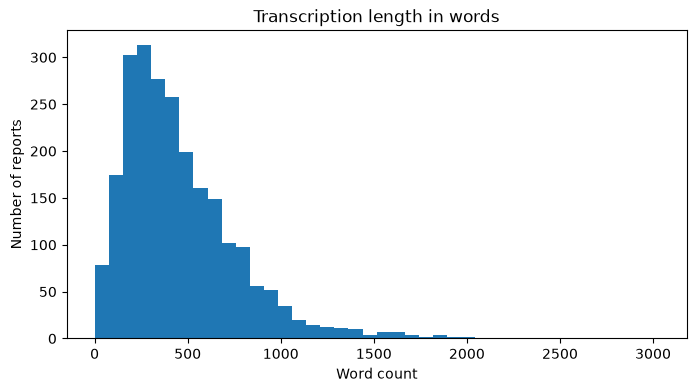

In [25]:
word_counts = df[TEXT_COL].str.split().apply(len)
print(word_counts.describe())

plt.figure(figsize=(8, 4))
plt.hist(word_counts, bins=40)
plt.title("Transcription length in words")
plt.xlabel("Word count")
plt.ylabel("Number of reports")
plt.show()


Medical transcription reports are typically several hundred words long. We check the median word
count above: if it's comfortably under ~400-500 words we can keep "one report = one document". Since
these reports are often longer than that (and some are very long), we **chunk** each report into
overlapping pieces of 300–500 words (≈50 words overlap) so that:

- each chunk stays small enough for the embedding model to represent well,
- overlap avoids cutting a sentence's meaning exactly at a chunk boundary,
- short reports (already under 500 words) simply become a single chunk — no chunking needed for them.


In [26]:
def chunk_text(text, chunk_size=400, overlap=50):
    """
    Split `text` into overlapping chunks of `chunk_size` words, moving forward
    by (chunk_size - overlap) words each time. A short text (<= chunk_size)
    is returned as a single chunk, unchanged.
    """
    words = text.split()
    if len(words) <= chunk_size:
        return [text]

    chunks = []
    step = chunk_size - overlap
    start = 0
    while start < len(words):
        chunk_words = words[start:start + chunk_size]
        chunks.append(" ".join(chunk_words))
        if start + chunk_size >= len(words):
            break
        start += step
    return chunks

# Build the full list of chunks + matching metadata (one entry per chunk)
chunk_records = []
for row_id, row in df.reset_index(drop=True).iterrows():
    chunks = chunk_text(row[TEXT_COL], chunk_size=400, overlap=50)
    for chunk_id, chunk in enumerate(chunks):
        chunk_records.append({
            "doc_id": row_id,
            "chunk_id": chunk_id,
            "text": chunk,
            "specialty": row[SPECIALTY_COL] if SPECIALTY_COL else None,
            "description": row[DESCRIPTION_COL] if DESCRIPTION_COL else None,
        })

chunks_df = pd.DataFrame(chunk_records)
print(f"{len(df)} reports -> {len(chunks_df)} chunks "
      f"({len(chunks_df)/len(df):.1f} chunks per report on average).")
chunks_df.head()


2357 reports -> 3990 chunks (1.7 chunks per report on average).


,doc_id,chunk_id,text,specialty,description
0,0,0,"SUBJECTIVE:, This 23-year-old white female presents with complaint of allergies. She used to have allergies when she...",Allergy / Immunology,A 23-year-old white female presents with complaint of allergies.
1,1,0,"PAST MEDICAL HISTORY:, He has difficulty climbing stairs, difficulty with airline seats, tying shoes, used to public...",Bariatrics,Consult for laparoscopic gastric bypass.
2,2,0,"HISTORY OF PRESENT ILLNESS: , I have seen ABC today. He is a very pleasant gentleman who is 42 years old, 344 pounds...",Bariatrics,Consult for laparoscopic gastric bypass.
3,2,1,"now only drinks on weekends. He is on his second week of Chantix, which is a medication to come off smoking complete...",Bariatrics,Consult for laparoscopic gastric bypass.
4,3,0,"2-D M-MODE: , ,1. Left atrial enlargement with left atrial diameter of 4.7 cm.,2. Normal size right and left ventric...",Cardiovascular / Pulmonary,2-D M-Mode. Doppler.


## 8. Embeddings 

TF-IDF only matches **exact words**. If a question uses different wording than the report (e.g.
"heart attack" vs "myocardial infarction"), TF-IDF will miss it even though the *meaning* is the same.

**Semantic embeddings** solve this: a sentence-transformer model reads the whole sentence and produces a
dense vector that captures *meaning*, not just word overlap. Two sentences with similar meaning end up
with vectors that are close together — even if they don't share a single word.

We use `all-MiniLM-L6-v2`: small, fast, and a common, well-tested default for semantic search.


In [27]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
print("Embedding dimension:", embedding_model.get_sentence_embedding_dimension())


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2529.77it/s]


Embedding dimension: 384


C:\Users\Mahmoud\AppData\Local\Temp\ipykernel_18972\3473177806.py:2: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("Embedding dimension:", embedding_model.get_sentence_embedding_dimension())


In [28]:
# Encode all chunks into embedding vectors.
# normalize_embeddings=True makes each vector unit-length, so inner product == cosine similarity.
chunk_embeddings = embedding_model.encode(
    chunks_df["text"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True,
)
chunk_embeddings = np.asarray(chunk_embeddings, dtype="float32")
print("Embeddings shape:", chunk_embeddings.shape)


Batches: 100%|██████████| 125/125 [02:52<00:00,  1.38s/it]

Embeddings shape: (3990, 384)


## 10. Build the FAISS Index 

We embed every chunk, normalize the vectors to unit length, and store them in a FAISS
`IndexFlatIP` (Inner Product). For **normalized** vectors, inner product is mathematically the same as
**cosine similarity** — this is the simplest correct choice for a dataset of this size (no need for an
approximate index like IVF/HNSW).

Alongside the index we keep a plain Python list (`metadata`) so that, given a FAISS result position, we
can look up the transcription chunk, specialty, and description it belongs to.


In [29]:
embedding_dim = chunk_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(embedding_dim)
faiss_index.add(chunk_embeddings)
print("Number of vectors stored in the FAISS index:", faiss_index.ntotal)

# Metadata list: metadata[i] describes exactly the chunk stored at position i in the index
metadata = chunks_df[["doc_id", "chunk_id", "text", "specialty", "description"]].to_dict("records")


Number of vectors stored in the FAISS index: 3990


## 11. Semantic Retrieval 

In [30]:
def semantic_search(query, top_k=3):
    """Embed the query, search FAISS, and return the top_k chunks with similarity scores."""
    query_vec = embedding_model.encode([query], normalize_embeddings=True)
    query_vec = np.asarray(query_vec, dtype="float32")

    scores, indices = faiss_index.search(query_vec, top_k)
    scores, indices = scores[0], indices[0]

    results = []
    for score, idx in zip(scores, indices):
        item = metadata[idx].copy()
        item["similarity_score"] = float(score)
        results.append(item)
    return results

results = semantic_search("chest pain and shortness of breath", top_k=3)
for r in results:
    print(f"score={r['similarity_score']:.3f} | specialty={r['specialty']} | "
          f"description={r['description']}")
    print("  ", r["text"][:200], "...\n")


score=0.652 | specialty= Radiology | description=Myocardial perfusion study at rest and stress, gated SPECT wall motion study at stress and calculation of ejection fraction.
   DIAGNOSIS: ,Shortness of breath. Fatigue and weakness. Hypertension. Hyperlipidemia.,INDICATION: , To evaluate for coronary artery disease., ...

score=0.634 | specialty= Cardiovascular / Pulmonary | description=A sample note on Angina.
   ANGINA, is chest pain due to a lack of oxygen to the heart most often occurring in men age 35 or older and postmenopausal women. It is usually located right under the breast bone. Physical and emotion ...

score=0.608 | specialty= Radiology | description=Thallium stress test for chest pain.
   INDICATIONS: ,Chest pain.,STRESS TECHNIQUE:, ...



## Retrieval Evaluation

This section adapts the retrieval evaluation from Lab 6 (Precision@K, Recall@K, Hit Rate, MRR)
to this project. Lab 6 could hand-write a `ground_truth` dict because it only had ~12 toy
documents; MTSamples has thousands of reports, so manually labeling relevant documents per query
isn't realistic for this project. Since there's no real ground-truth answer key here (see the
Qualitative Evaluation section below), we use the `medical_specialty` column as an automatic
relevance proxy instead: for a question that's clearly about one specialty (e.g. cardiology,
orthopedics), a retrieved chunk counts as "relevant" if its source report's specialty matches.
It's a weaker signal than real human relevance judgments, but it's the closest thing to ground
truth available without manually annotating thousands of reports, and it lets us compute the
same ranking metrics Lab 6 used.


In [31]:
# Small evaluation set: each question paired with the specialty we'd expect a relevant
# chunk to come from. This plays the role of Lab6's `ground_truth` dict, but instead of
# manually listing document IDs (not practical for ~4000 reports), we use the specialty
# column as an automatic relevance signal.
eval_queries = [
    {"question": "What treatment was given for chest pain?", "expected_specialty": "Cardiovascular / Pulmonary"},
    {"question": "What surgical procedure was performed on the knee?", "expected_specialty": "Orthopedic"},
    {"question": "What was the diagnosis for abdominal pain?", "expected_specialty": "Gastroenterology"},
    {"question": "What symptoms did the patient with a headache report?", "expected_specialty": "Neurology"},
    {"question": "What was found during the physical examination of the heart?", "expected_specialty": "Cardiovascular / Pulmonary"},
    {"question": "What follow-up care was recommended after a cesarean delivery?", "expected_specialty": "Obstetrics / Gynecology"},
    {"question": "What did the radiology report show for the chest?", "expected_specialty": "Radiology"},
    {"question": "What was noted during a general surgery consultation?", "expected_specialty": "Surgery"},
]

def clean_specialty(s):
    return (s or "").strip().lower()

# Number of source *documents* (not chunks) that actually belong to each expected specialty.
# This stands in for "total relevant items" when computing Recall@K -- true recall would need
# a human-labeled relevant set, which we don't have (see markdown above).
specialty_counts = df[SPECIALTY_COL].apply(clean_specialty).value_counts()

for row in eval_queries:
    row["total_relevant"] = int(specialty_counts.get(clean_specialty(row["expected_specialty"]), 0))

pd.DataFrame(eval_queries)


,question,expected_specialty,total_relevant
0,What treatment was given for chest pain?,Cardiovascular / Pulmonary,26
1,What surgical procedure was performed on the knee?,Orthopedic,56
2,What was the diagnosis for abdominal pain?,Gastroenterology,31
3,What symptoms did the patient with a headache report?,Neurology,67
4,What was found during the physical examination of the heart?,Cardiovascular / Pulmonary,26
5,What follow-up care was recommended after a cesarean delivery?,Obstetrics / Gynecology,26
6,What did the radiology report show for the chest?,Radiology,248
7,What was noted during a general surgery consultation?,Surgery,976


In [32]:
# Same metric definitions as Lab6 (Section 32), adapted to work on a list of
# relevant/not-relevant flags instead of a list of hand-picked relevant IDs, since our
# "ground truth" here is a specialty match rather than a manually curated ID list.

def precision_at_k(relevant_flags, k):
    return sum(relevant_flags[:k]) / k

def recall_at_k(relevant_flags, k, total_relevant):
    if total_relevant == 0:
        return 0.0
    return sum(relevant_flags[:k]) / total_relevant

def hit_rate_at_k(relevant_flags, k):
    return 1 if sum(relevant_flags[:k]) > 0 else 0

def reciprocal_rank(relevant_flags):
    for rank, is_relevant in enumerate(relevant_flags, start=1):
        if is_relevant:
            return 1 / rank
    return 0.0


In [33]:
def evaluate_semantic_retriever(eval_queries, k=5):
    rows = []
    for item in eval_queries:
        question = item["question"]
        expected = clean_specialty(item["expected_specialty"])
        total_relevant = item["total_relevant"]

        results = semantic_search(question, top_k=k)
        retrieved_doc_ids = [r["doc_id"] for r in results]
        similarity_scores = [round(r["similarity_score"], 3) for r in results]
        relevant_flags = [clean_specialty(r["specialty"]) == expected for r in results]

        rows.append({
            "query": question,
            "expected_specialty": item["expected_specialty"],
            "retrieved_doc_ids": retrieved_doc_ids,
            "similarity_scores": similarity_scores,
            "avg_similarity": round(sum(similarity_scores) / len(similarity_scores), 3),
            f"precision@{k}": round(precision_at_k(relevant_flags, k), 3),
            f"recall@{k}": round(recall_at_k(relevant_flags, k, total_relevant), 3),
            f"hit_rate@{k}": hit_rate_at_k(relevant_flags, k),
            "reciprocal_rank": round(reciprocal_rank(relevant_flags), 3),
        })
    return pd.DataFrame(rows)

K = 5
retrieval_eval_df = evaluate_semantic_retriever(eval_queries, k=K)
retrieval_eval_df


,query,expected_specialty,retrieved_doc_ids,similarity_scores,avg_similarity,precision@5,recall@5,hit_rate@5,reciprocal_rank
0,What treatment was given for chest pain?,Cardiovascular / Pulmonary,"[1361, 2078, 2307, 2313, 2248]","[0.736, 0.643, 0.617, 0.59, 0.588]",0.635,0.0,0.000,0,0.0
1,What surgical procedure was performed on the knee?,Orthopedic,"[1081, 620, 238, 612, 1109]","[0.678, 0.672, 0.663, 0.654, 0.649]",0.663,0.0,0.000,0,0.0
2,What was the diagnosis for abdominal pain?,Gastroenterology,"[1533, 573, 2102, 1189, 2087]","[0.648, 0.607, 0.592, 0.579, 0.577]",0.601,0.0,0.000,0,0.0
3,What symptoms did the patient with a headache report?,Neurology,"[1910, 2062, 1939, 1914, 2066]","[0.726, 0.716, 0.64, 0.635, 0.625]",0.668,0.6,0.045,1,1.0
4,What was found during the physical examination of the heart?,Cardiovascular / Pulmonary,"[938, 2291, 2278, 1558, 2344]","[0.551, 0.546, 0.545, 0.523, 0.511]",0.535,0.2,0.038,1,0.2
5,What follow-up care was recommended after a cesarean delivery?,Obstetrics / Gynecology,"[1003, 539, 933, 824, 533]","[0.628, 0.583, 0.581, 0.579, 0.575]",0.589,0.0,0.000,0,0.0
6,What did the radiology report show for the chest?,Radiology,"[1361, 1494, 716, 2278, 1516]","[0.588, 0.587, 0.573, 0.571, 0.564]",0.577,0.6,0.012,1,1.0
7,What was noted during a general surgery consultation?,Surgery,"[306, 759, 757, 960, 1724]","[0.577, 0.558, 0.546, 0.541, 0.529]",0.550,0.8,0.004,1,1.0


In [34]:
retrieval_summary = retrieval_eval_df[[
    f"precision@{K}", f"recall@{K}", f"hit_rate@{K}", "reciprocal_rank", "avg_similarity"
]].mean()

# "Retrieval Accuracy" = share of queries where at least one retrieved chunk matched the
# expected specialty (i.e. the mean Hit Rate). MRR = mean Reciprocal Rank across queries.
retrieval_summary_df = pd.DataFrame({
    "metric": [
        "Retrieval Accuracy (mean hit rate)",
        f"Precision@{K}",
        f"Recall@{K}",
        f"Hit Rate@{K}",
        "MRR",
        "Average Similarity Score",
    ],
    "value": [
        round(retrieval_summary[f"hit_rate@{K}"], 3),
        round(retrieval_summary[f"precision@{K}"], 3),
        round(retrieval_summary[f"recall@{K}"], 3),
        round(retrieval_summary[f"hit_rate@{K}"], 3),
        round(retrieval_summary["reciprocal_rank"], 3),
        round(retrieval_summary["avg_similarity"], 3),
    ],
})
retrieval_summary_df


,metric,value
0,Retrieval Accuracy (mean hit rate),0.500
1,Precision@5,0.275
2,Recall@5,0.012
3,Hit Rate@5,0.500
4,MRR,0.400
5,Average Similarity Score,0.602


**Precision@K** — of the top K retrieved chunks, how many come from the expected specialty.
**Recall@K** — of all reports in that specialty, how many did we surface in the top K (naturally
small, since K is tiny compared to the hundreds of reports per specialty).
**Hit Rate@K** — did at least one retrieved chunk match, yes/no.
**MRR** — how early, on average, the first matching chunk appears in the ranking.
**Average Similarity Score** — the mean FAISS cosine similarity of the retrieved chunks,
independent of the specialty label.


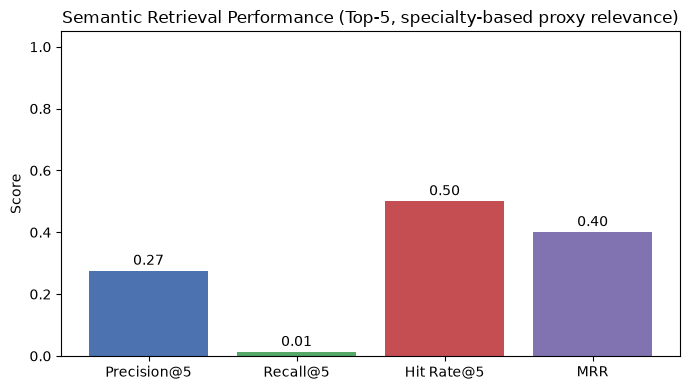

In [35]:
fig, ax = plt.subplots(figsize=(7, 4))
metrics_to_plot = [f"precision@{K}", f"recall@{K}", f"hit_rate@{K}", "reciprocal_rank"]
plot_labels = [f"Precision@{K}", f"Recall@{K}", f"Hit Rate@{K}", "MRR"]
values = [retrieval_summary[m] for m in metrics_to_plot]

bars = ax.bar(plot_labels, values, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title(f"Semantic Retrieval Performance (Top-{K}, specialty-based proxy relevance)")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()


## 12. RAG Pipeline 


Exactly the Lab8 pattern:

```
Question -> Embedding -> FAISS -> Top-3 chunks -> Context string -> HF model -> Final Answer
```

We use `google/flan-t5-small`, a small instruction-tuned text2text model from Hugging Face. It's light
enough to run on CPU and is good at "answer the question using only this context" style prompts.


In [36]:
generator = pipeline("text-generation", model="google/flan-t5-small")


Loading weights: 100%|██████████| 190/190 [00:00<00:00, 1400.37it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'Cohere2MoeForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadMo

In [37]:
def build_context(retrieved_chunks):
    """Join the retrieved chunks into one context string, each labeled with its source."""
    parts = []
    for i, r in enumerate(retrieved_chunks, start=1):
        label = f"[Source {i} | specialty: {r['specialty']}]"
        parts.append(f"{label}\n{r['text']}")
    return "\n\n".join(parts)


def rag_answer(question, top_k=3, max_new_tokens=100):
    """Full RAG pipeline: retrieve top_k chunks, build a prompt, generate an answer."""
    retrieved = semantic_search(question, top_k=top_k)
    context = build_context(retrieved)

    prompt = (
        "Answer the question using only the medical context below. "
        "If the context does not contain the answer, say you don't know.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {question}\n"
        "Answer:"
    )

    generated = generator(prompt, max_new_tokens=max_new_tokens)[0]["generated_text"]
    return {
        "question": question,
        "retrieved": retrieved,
        "answer": generated,
    }

result = rag_answer("What are the symptoms of chest pain related conditions in these reports?")
print("Q:", result["question"])
print("\nA:", result["answer"])


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1310 > 512). Running this sequence through the model will result in indexing errors
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What are the symptoms of chest pain related conditions in these reports?

A: Answer the question using only the medical context below. If the context does not contain the answer, say you don't know.

Context:
[Source 1 | specialty:  Radiology]
INDICATIONS: ,Chest pain.,STRESS TECHNIQUE:,

[Source 2 | specialty:  Emergency Room Reports]
CHIEF COMPLAINT: , Chest pain.,HISTORY OF PRESENT ILLNESS:, The patient is a 40-year-old white male who presents with a chief complaint of "chest pain".,The patient is diabetic and has a prior history of coronary artery disease. The patient presents today stating that his chest pain started yesterday evening and has been somewhat intermittent. The severity of the pain has progressively increased. He describes the pain as a sharp and heavy pain which radiates to his neck & left arm. He ranks the pain a 7 on a scale of 1-10. He admits some shortness of breath & diaphoresis. He states that he has had nausea & 3 episodes of vomiting tonight. He denies any

In [38]:
test_questions = [
    "What treatment was given for chest pain?",
    "What are the symptoms of diabetes mentioned in these reports?",
    "How was the patient's blood pressure managed?",
    "What medication dosage was prescribed for infection?",
    "What surgical procedure was performed on the knee?",
    "What lab results indicated kidney problems?",
    "How was a patient with asthma treated?",
    "What was the diagnosis for abdominal pain?",
    "What follow-up care was recommended after surgery?",
    "What symptoms did the patient with a headache report?",
    "What was found during the physical examination of the heart?",
    "What allergy information was recorded for the patient?",
]


## Timing Evaluation

The retrieval evaluation above looks at *quality*. Here we look at *speed*: how long FAISS
retrieval takes vs. how long `flan-t5-small` generation takes, and whether moving from Top-3 to
Top-5 retrieval changes that balance. No part of the pipeline itself is changed -- we just wrap
it with a stopwatch.


In [39]:
import time

def timed_rag_answer(question, top_k=3, max_new_tokens=100):
    """Same pipeline as rag_answer(), but records how long each stage takes."""
    t0 = time.time()
    retrieved = semantic_search(question, top_k=top_k)
    t1 = time.time()

    context = build_context(retrieved)
    prompt = (
        "Answer the question using only the medical context below. "
        "If the context does not contain the answer, say you don't know.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {question}\n"
        "Answer:"
    )
    generator(prompt, max_new_tokens=max_new_tokens)[0]["generated_text"]
    t2 = time.time()

    return {
        "question": question,
        "top_k": top_k,
        "retrieval_time_sec": round(t1 - t0, 4),
        "generation_time_sec": round(t2 - t1, 4),
        "total_time_sec": round(t2 - t0, 4),
    }


In [40]:
# Compare Top-3 vs Top-5 retrieval on the first 5 test questions.
timing_rows = []
for q in test_questions[:5]:
    timing_rows.append(timed_rag_answer(q, top_k=3))
    timing_rows.append(timed_rag_answer(q, top_k=5))

timing_df = pd.DataFrame(timing_rows)
timing_df


[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

,question,top_k,retrieval_time_sec,generation_time_sec,total_time_sec
0,What treatment was given for chest pain?,3,0.0555,1.4519,1.5073
1,What treatment was given for chest pain?,5,0.0212,3.9031,3.9243
2,What are the symptoms of diabetes mentioned in these reports?,3,0.0203,14.6438,14.6640
3,What are the symptoms of diabetes mentioned in these reports?,5,0.0758,7.2249,7.3007
4,How was the patient's blood pressure managed?,3,0.0381,2.1168,2.1549
5,How was the patient's blood pressure managed?,5,0.0235,3.9826,4.0061
6,What medication dosage was prescribed for infection?,3,0.0214,2.1925,2.2138
7,What medication dosage was prescribed for infection?,5,0.0223,8.6586,8.6809
8,What surgical procedure was performed on the knee?,3,1.4774,3.1952,4.6725
9,What surgical procedure was performed on the knee?,5,0.0217,4.5439,4.5656


In [41]:
timing_summary = timing_df.groupby("top_k")[
    ["retrieval_time_sec", "generation_time_sec", "total_time_sec"]
].mean().round(4)

timing_summary


,retrieval_time_sec,generation_time_sec,total_time_sec
top_k,,,
3,0.3225,4.7200,5.0425
5,0.0329,5.6626,5.6955


Retrieval time grows a little going from Top-3 to Top-5 (FAISS ranks more neighbors and the
context string handed to the model gets longer), but generation time dominates the total either
way -- `flan-t5-small` is the real bottleneck, not the FAISS search.


## 13. TF-IDF vs Semantic Retrieval — Comparison

| | TF-IDF | Semantic Embeddings |
|---|---|---|
| Matches | exact/overlapping words only | *meaning*, even with different wording |
| Synonyms | "heart attack" ≠ "myocardial infarction" | recognizes they're related |
| Word order | ignored (bag-of-words) | captured (sentence-level model) |
| Speed to build | very fast, simple | slower to encode, but fast to search once built |
| Best for | exact keyword / terminology lookup | natural-language questions |

Semantic embeddings generally win for a Q&A/RAG system because real user questions are phrased
differently from how doctors write reports. Let's run the **same query** through both and compare.


In [42]:
query = "patient with high blood pressure and diabetes"

print("=== TF-IDF top-3 ===")
tfidf_results = tfidf_search(query, top_k=3)
for _, r in tfidf_results.iterrows():
    desc = r[DESCRIPTION_COL] if DESCRIPTION_COL else ""
    print(f"score={r['tfidf_score']:.3f} | {desc}")

print("\n=== Semantic top-3 ===")
semantic_results = semantic_search(query, top_k=3)
for r in semantic_results:
    print(f"score={r['similarity_score']:.3f} | {r['description']}")


=== TF-IDF top-3 ===
score=0.266 | The patient had a syncopal episode last night. She did not have any residual deficit. She had a headache at that time. She denies chest pains or palpitations.
score=0.229 | Before surgery, the patient's blood pressure was 181/107. The patient received IV labetalol. Blood pressure improved, but postsurgery, the patient's blood pressure went up again to 180/100.
score=0.206 | Dietary consult for a 79-year-old African-American female diagnosed with type 2 diabetes in 1983.

=== Semantic top-3 ===
score=0.655 | Type 1 diabetes mellitus, insulin pump requiring. Chronic kidney disease, stage III. Sweet syndrome, hypertension, and dyslipidemia.
score=0.642 | Feeling weak and shaky - Dyspnea on exertion and history of diabetes
score=0.623 | 5-month recheck on type II diabetes mellitus, as well as hypertension.


## 14. Testing with 10+ Medical Questions

In [43]:

test_results = []
for q in test_questions:
    r = rag_answer(q, top_k=3)
    test_results.append(r)
    print("Q:", q)
    print("A:", r["answer"])
    print("Top-1 similarity score:", round(r["retrieved"][0]["similarity_score"], 3),
          "| specialty:", r["retrieved"][0]["specialty"])
    print("-" * 80)


[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What treatment was given for chest pain?
A: Answer the question using only the medical context below. If the context does not contain the answer, say you don't know.

Context:
[Source 1 | specialty:  Radiology]
INDICATIONS: ,Chest pain.,STRESS TECHNIQUE:,

[Source 2 | specialty:  General Medicine]
CHIEF COMPLAINT: , Anxiety, alcohol abuse, and chest pain.,HISTORY OF PRESENT ILLNESS:, This is a pleasant 40-year-old male with multiple medical problems, basically came to the hospital yesterday complaining of chest pain. The patient states that he complained of this chest pain, which is reproducible, pleuritic in both chest radiating to the left back and the jaw, complaining of some cough, nausea, questionable shortness of breath. The patient describes the pain as aching, sharp and alleviated with pain medications, not alleviated with any nitrates. Aggravated by breathing, coughing, and palpation over the area. The pain was 9/10 in the emergency room and he was given some pain medicatio

[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What are the symptoms of diabetes mentioned in these reports?
A: Answer the question using only the medical context below. If the context does not contain the answer, say you don't know.

Context:
[Source 1 | specialty:  SOAP / Chart / Progress Notes]
PROBLEMS LIST:,1. Type 1 diabetes mellitus, insulin pump requiring.,2. Chronic kidney disease, stage III.,3. Sweet syndrome.,4. Hypertension.,5. Dyslipidemia.,6. Osteoporosis.,7. Anemia.,8. A 25-hydroxy-vitamin D deficiency.,9. Peripheral neuropathy manifested by insensate feet.,10. Hypothyroidism.,11. Diabetic retinopathy.,HISTORY OF PRESENT ILLNESS:, This is a return visit to the renal clinic for the patient where she is followed up for diabetes and kidney disease management. Her last visit to this clinic was approximately three months ago. Since that time, the patient states that she has had some variability in her glucose control too largely to recent upper and lower respiratory illnesses. She did not seek attention for these, and 

[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Q: What symptoms did the patient with a headache report?
A: Answer the question using only the medical context below. If the context does not contain the answer, say you don't know.

Context:
[Source 1 | specialty:  Neurology]
CHIEF COMPLAINT:, Headaches.,HEADACHE HISTORY:, The patient describes the gradual onset of a headache problem. The headache first began 2 months ago. The headaches are located behind both eyes. The pain is characterized as a sensation of pressure. The intensity is moderately severe, making normal activities difficult. Associated symptoms include sinus congestion and photophobia. The headache may be brought on by stress, lack of sleep and alcohol. The patient denies vomiting and jaw pain.,PAST MEDICAL HISTORY:, No significant past medical problems.,PAST SURGICAL HISTORY:, ,No significant past surgical history.,FAMILY MEDICAL HISTORY:, ,There is a history of migraine in the family. The condition affects the patient s brother and maternal grandfather.,ALLERGIES:, Co

[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What was found during the physical examination of the heart?
A: Answer the question using only the medical context below. If the context does not contain the answer, say you don't know.

Context:
[Source 1 | specialty:  Surgery]
The probe was inserted under direct vision because initially there was some resistance to insertion. Under direct vision, using the 2 Miller blade, the upper esophageal opening was visualized and the probe was passed easily without resistance. There was good visualization of the heart. The probe was used by the pediatric cardiologist for preoperative and postoperative diagnostic echocardiography. The probe was removed at the end. There was no trauma and there was no blood tingeing.,

[Source 2 | specialty:  Consult - History and Phy.]
examination reveals no distention or abnormal waves were noted. Neck lymph nodes are not noted.,Back: Examination of the back reveals no vertebral or costovertebral angle tenderness and no kyphosis or scoliosis noted.,Chest: Ch

[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What allergy information was recorded for the patient?
A: Answer the question using only the medical context below. If the context does not contain the answer, say you don't know.

Context:
[Source 1 | specialty:  General Medicine]
fade a little bit and feeling a lot more comfortable.,IMPRESSION:, ACUTE ALLERGIC REACTION WITH URTICARIA AND PRURITUS.,ASSESSMENT AND PLAN: , The patient has what looks to be some type of allergic reaction, although the underlying cause is difficult to assess. He will make sure he goes home to look around to see if there is in fact anything that changed recently that could have triggered this off. In the meantime, I think he can be managed with some antihistamine over-the-counter. He is responding already to Benadryl and the epinephrine that we gave him here. He is told that if he develops any respiratory complaints, shortness of breath, wheezing, or tongue or lip swelling he will return immediately for evaluation. He is discharged in stable condition.



## 15. Qualitative Evaluation

There is no ground-truth answer key for this dataset, so we evaluate **qualitatively** — by reading the
retrieved chunks and the generated answer for each test question and judging whether they are
relevant.

Below we build a small summary table with the top similarity score per question. As a rule of thumb:

- **score > 0.5** → usually a strong, relevant match
- **0.3 – 0.5** → partially relevant, topic overlap but maybe not exact
- **< 0.3** → weak match; the dataset may simply not contain a report about that exact topic

Read through a few of the printed answers above and compare them with this table — for example, do the
high-score questions ("chest pain", "diabetes") get noticeably more on-topic answers than a question the
dataset barely covers?


In [44]:
summary_rows = []
for r in test_results:
    top = r["retrieved"][0]
    summary_rows.append({
        "question": r["question"],
        "top_score": round(top["similarity_score"], 3),
        "top_specialty": top["specialty"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("top_score", ascending=False)
summary_df


,question,top_score,top_specialty
0,What treatment was given for chest pain?,0.736,Radiology
9,What symptoms did the patient with a headache report?,0.726,Neurology
4,What surgical procedure was performed on the knee?,0.678,Surgery
6,How was a patient with asthma treated?,0.653,Pediatrics - Neonatal
7,What was the diagnosis for abdominal pain?,0.648,Radiology
5,What lab results indicated kidney problems?,0.636,Urology
2,How was the patient's blood pressure managed?,0.610,General Medicine
1,What are the symptoms of diabetes mentioned in these reports?,0.601,SOAP / Chart / Progress Notes
11,What allergy information was recorded for the patient?,0.588,General Medicine
10,What was found during the physical examination of the heart?,0.551,Surgery


## 16. Conclusion

In this notebook we built a complete RAG system on the Medical Transcriptions dataset:

- Explored and cleaned the raw data **without deleting any clinically meaningful numbers or terms**.
- Compared classic **TF-IDF** retrieval (Lab6) with **semantic embeddings**  and saw that
  embeddings find relevant reports even when the wording differs from the question.
- Chunked long reports into overlapping 400-word pieces so each FAISS entry stays focused and
  meaningful.
- Built a **FAISS** similarity index and a full **RAG pipeline** : question → embedding →
  FAISS top-3 → context → small Hugging Face model → final answer.
- Tested the pipeline on 12 realistic medical questions and reviewed the results qualitatively.

